In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [30]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

In [31]:
df= pd.read_csv('train.csv')

In [32]:
df=df.drop(['PassengerId','Name','Ticket','Pclass','Sex','SibSp','Parch','Cabin','Embarked'], axis=1)

In [33]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Age       714 non-null    float64
 2   Fare      891 non-null    float64
dtypes: float64(2), int64(1)
memory usage: 21.0 KB


In [35]:
df.isnull().mean()

Survived    0.000000
Age         0.198653
Fare        0.000000
dtype: float64

In [36]:
X = df.drop(columns=['Survived'])
y=df['Survived']

In [37]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [38]:
X_train.shape, X_test.shape

((712, 2), (179, 2))

In [39]:
X_train.isnull().mean()

Age     0.196629
Fare    0.000000
dtype: float64

In [40]:
median_age = X_train['Age'].median()
mean_age = X_train['Age'].mean()

In [41]:
X_train['Age_median'] =X_train['Age'].fillna(median_age)
X_train['Age_mean'] =X_train['Age'].fillna(mean_age)

In [42]:
X_train.sample(5)

,Age,Fare,Age_median,Age_mean
190,32.0,13.0000,32.0,32.000000
461,34.0,8.0500,34.0,34.000000
826,NaN,56.4958,28.0,29.498846
614,35.0,8.0500,35.0,35.000000
798,30.0,7.2292,30.0,30.000000


In [43]:
print('Original Age variable variance: ',X_train['Age'].var())
print('Age Variance after median Imputation ',X_train['Age_median'].var())
print('Age Variance after mean Imputation ',X_train['Age_mean'].var())

Original Age variable variance:  210.2517072477438
Age Variance after median Imputation  169.20731007048096
Age Variance after mean Imputation  168.8519336687225


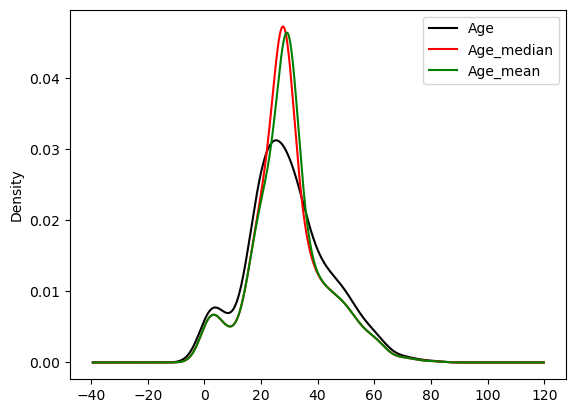

In [44]:
fig, ax= plt.subplots()
X_train['Age'].plot(kind='kde',ax=ax,color='black')
X_train['Age_median'].plot(kind='kde',ax=ax,color='red')
X_train['Age_mean'].plot(kind='kde',ax=ax,color='green')
lines, labels = ax.get_legend_handles_labels()
ax.legend(lines, labels, loc='best')

In [45]:
X_train.cov()

,Age,Fare,Age_median,Age_mean
Age,210.251707,71.580633,210.251707,210.251707
Fare,71.580633,2700.831981,61.261919,57.485994
Age_median,210.251707,61.261919,169.207310,168.851934
Age_mean,210.251707,57.485994,168.851934,168.851934


<Axes: >

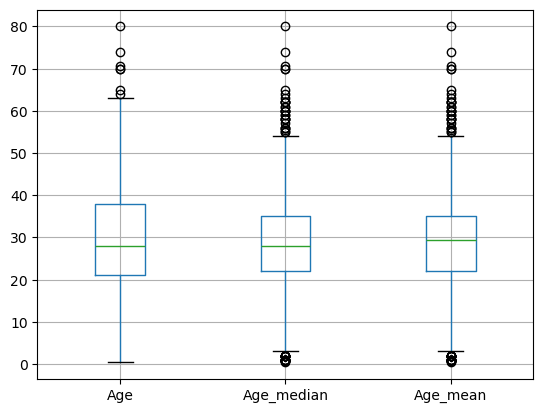

In [46]:
X_train[['Age','Age_median','Age_mean']].boxplot()

Using SKlearn

In [47]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [48]:
imputer1 = SimpleImputer(strategy='median')
imputer2 = SimpleImputer(strategy='mean')

In [49]:
trf = ColumnTransformer([
    ('imputer1',imputer1,['Age'])
],remainder='passthrough')

In [50]:
trf.fit(X_train)

,transformers,"[('imputer1', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


In [52]:
trf.named_transformers_['imputer1'].statistics_

array([28.75])

In [53]:
X_train =trf.transform(X_train)
X_test =trf.transform(X_test)

In [54]:
X_train

array([[ 40.    ,  27.7208],
       [  4.    ,  16.7   ],
       [ 47.    ,   9.    ],
       ...,
       [ 71.    ,  49.5042],
       [ 28.75  , 221.7792],
       [ 28.75  ,  25.925 ]], shape=(712, 2))